In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost
from xgboost import XGBRegressor

In [31]:
df = pd.read_csv("../data/processed/cleaned_used_cars.csv")


In [32]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. position
2. model_year
3. body_type
4. transmission
5. fuel_type
6. full_vehicle_name
7. brand
8. model
9. vehicle_name
10. centralVariantId
11. variantName
12. city_x
13. price
14. discountValue
15. msp
16. utype
17. tmGaadiStore
18. transmissionType
19. carType
20. top_features
21. comfort_features
22. interior_features
23. exterior_features
24. safety_features
25. Color
26. Engine Type
27. Displacement
28. Max Power
29. Max Torque
30. No of Cylinder
31. Values per Cylinder
32. Turbo Charger
33. Super Charger
34. Length
35. Width
36. Height
37. Wheel Base
38. Gear Box
39. Drive Type
40. Seating Capacity
41. Steering Type
42. Front Brake Type
43. Rear Brake Type
44. Tyre Type
45. No Door Numbers
46. model_type_new
47. page_title
48. seller_type_new
49. transmission_type
50. car_type_new
51. model_name
52. price_range_segment
53. state
54. transmission_type_new
55. km_driven
56. model_new
57. vehicle_type_new
58. engine_cc
59. car_segment
60. used_carid
61. city_name_new
62. city_y


In [33]:
df[[
    "msp",
    "discountValue",
    "utype",
    "tmGaadiStore",
    "transmissionType",
    "carType",
    "seller_type_new",
    "vehicle_type_new"
]].head(10).T

,0,1,2,3,4,5,6,7,8,9
msp,0,0,0,0,0,0,0,0,0,0
discountValue,0,0,0,0,0,0,0,0,0,0
utype,Dealer,Dealer,Dealer,Dealer,Dealer,Dealer,Dealer,Dealer,Dealer,Dealer
tmGaadiStore,False,False,False,False,False,False,False,False,False,False
transmissionType,Manual,Manual,Manual,Manual,Manual,Manual,Manual,Manual,Manual,Manual
carType,corporate,corporate,corporate,corporate,partner,partner,partner,partner,partner,partner
seller_type_new,dealer,dealer,dealer,dealer,dealer,dealer,dealer,dealer,dealer,dealer
vehicle_type_new,car,car,car,car,car,car,car,car,car,car


In [34]:
df[[
    "msp",
    "discountValue"
]].describe()

,msp,discountValue
count,3.781300e+04,37813.000000
mean,5.426705e+01,73.281702
std,7.477564e+03,2805.783272
min,0.000000e+00,0.000000
25%,0.000000e+00,0.000000
50%,0.000000e+00,0.000000
75%,0.000000e+00,0.000000
max,1.093000e+06,200000.000000


In [35]:
df["vehicle_type_new"].value_counts()

vehicle_type_new
car    37813
Name: count, dtype: int64

In [36]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

model_type_new
car_type_new
vehicle_type_new


In [37]:
df.nunique().sort_values(ascending=False).head(25)

page_title           37813
used_carid           37813
km_driven            23862
price                 6864
centralVariantId      4585
full_vehicle_name     4159
vehicle_name          4159
variant_name          4131
variant_new           4131
variantName           3488
safety_features       2116
comfort_features      2016
exterior_features     1893
exterior_color         798
Color                  798
Engine Type            658
city_y                 617
city_name_new          617
city_x                 617
Max Power              570
interior_features      527
Length                 410
top_features           400
model                  382
model_new              382
dtype: int64

In [38]:
drop_columns = [
    # Target leakage
    "price_segment",
    "price_segment_new",
    "price_range_segment",

    # IDs
    "used_carid",
    "position",
    "centralVariantId",

    # Duplicate name columns
    "page_title",
    "full_vehicle_name",
    "vehicle_name",
    "model_name",
    "model_new",
    "variant_name",
    "variant_new",
    "variantName",

    # Duplicate categorical columns
    "city_y",
    "city_name_new",
    "brand_new",
    "body_type_new",
    "transmission_type",
    "transmissionType",
    "transmission_type_new",

    # Constant columns
    "model_type_new",
    "car_type_new",
    "vehicle_type_new",

    # Mostly empty / uninformative
    "msp",
    "discountValue",

    # Duplicate seller info
    "carType"
]

model_df = df.drop(columns=drop_columns)

model_df.shape

(37813, 45)

In [39]:
model_df.columns.tolist()

['model_year',
 'body_type',
 'transmission',
 'fuel_type',
 'brand',
 'model',
 'city_x',
 'price',
 'utype',
 'tmGaadiStore',
 'top_features',
 'comfort_features',
 'interior_features',
 'exterior_features',
 'safety_features',
 'Color',
 'Engine Type',
 'Displacement',
 'Max Power',
 'Max Torque',
 'No of Cylinder',
 'Values per Cylinder',
 'Turbo Charger',
 'Super Charger',
 'Length',
 'Width',
 'Height',
 'Wheel Base',
 'Gear Box',
 'Drive Type',
 'Seating Capacity',
 'Steering Type',
 'Front Brake Type',
 'Rear Brake Type',
 'Tyre Type',
 'No Door Numbers',
 'seller_type_new',
 'state',
 'km_driven',
 'engine_cc',
 'car_segment',
 'owner_type_new',
 'exterior_color',
 'owner_type',
 'Fuel Suppy System']

In [40]:
df[["owner_type", "owner_type_new"]].head(20)

,owner_type,owner_type_new
0,first,first
1,first,first
2,second,second
3,second,second
4,first,first
5,first,first
6,first,first
7,first,first
8,first,first
9,second,second


In [41]:
df[["utype", "seller_type_new"]].head(20)

,utype,seller_type_new
0,Dealer,dealer
1,Dealer,dealer
2,Dealer,dealer
3,Dealer,dealer
4,Dealer,dealer
5,Dealer,dealer
6,Dealer,dealer
7,Dealer,dealer
8,Dealer,dealer
9,Dealer,dealer


In [42]:
df[["Color", "exterior_color"]].head(20)

,Color,exterior_color
0,Silver,Silver
1,Grey,Grey
2,Silver,Silver
3,Silver,Silver
4,White,White
5,White,White
6,Blue,Blue
7,Grey,Grey
8,Silver,Silver
9,Silver,Silver


In [43]:
df[["engine_cc", "Displacement"]].head(20)

,engine_cc,Displacement
0,500cc-1000cc,998.0
1,500cc-1000cc,998.0
2,1000cc-2000cc,1198.0
3,500cc-1000cc,998.0
4,1000cc-2000cc,1462.0
5,500cc-1000cc,998.0
6,500cc-1000cc,796.0
7,1000cc-2000cc,1197.0
8,500cc-1000cc,998.0
9,500cc-1000cc,998.0


In [44]:
drop_columns.extend([
    "owner_type_new",
    "seller_type_new",
    "exterior_color",
    "top_features",
    "comfort_features",
    "interior_features",
    "exterior_features",
    "safety_features"
])

model_df = df.drop(columns=drop_columns)

model_df.isnull().sum().sort_values(ascending=False)

model_year             0
body_type              0
transmission           0
fuel_type              0
brand                  0
model                  0
city_x                 0
price                  0
utype                  0
tmGaadiStore           0
Color                  0
Engine Type            0
Displacement           0
Max Power              0
Max Torque             0
No of Cylinder         0
Values per Cylinder    0
Turbo Charger          0
Super Charger          0
Length                 0
Width                  0
Height                 0
Wheel Base             0
Gear Box               0
Drive Type             0
Seating Capacity       0
Steering Type          0
Front Brake Type       0
Rear Brake Type        0
Tyre Type              0
No Door Numbers        0
state                  0
km_driven              0
engine_cc              0
car_segment            0
owner_type             0
Fuel Suppy System      0
dtype: int64

In [45]:
X = model_df.drop("price", axis=1)
y = model_df["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (37813, 36)
Target shape: (37813,)


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set :", X_train.shape)
print("Testing set  :", X_test.shape)

Training set : (30250, 36)
Testing set  : (7563, 36)


In [47]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['body_type', 'transmission', 'fuel_type', 'brand', 'model', 'city_x', 'utype', 'Color', 'Engine Type', 'Turbo Charger', 'Super Charger', 'Gear Box', 'Drive Type', 'Steering Type', 'Front Brake Type', 'Rear Brake Type', 'Tyre Type', 'state', 'engine_cc', 'car_segment', 'owner_type', 'Fuel Suppy System']

Numerical Features:
['model_year', 'tmGaadiStore', 'Displacement', 'Max Power', 'Max Torque', 'No of Cylinder', 'Values per Cylinder', 'Length', 'Width', 'Height', 'Wheel Base', 'Seating Capacity', 'No Door Numbers', 'km_driven']


C:\Users\hp\AppData\Local\Temp\ipykernel_7128\3793086365.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [49]:
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [50]:
linear_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['model_year','body_type','transmission',...,'car_segment','owner_type', 'Fuel Suppy System']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of

In [51]:
y_pred_lr = linear_pipeline.predict(X_test)

In [52]:
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MAE : 312,777.31
RMSE: 658,020.66
R² Score: 0.6369


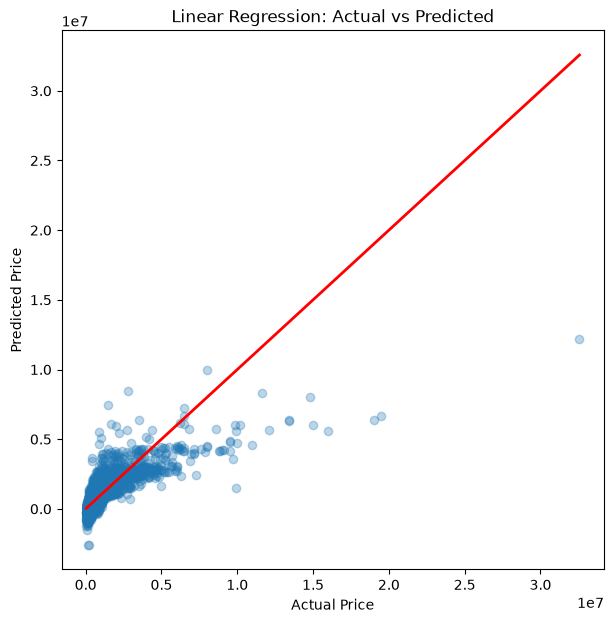

In [53]:
y_pred_lr = linear_pipeline.predict(X_test)

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_lr, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

Insight: The Actual vs Predicted plot shows that Linear Regression predicts low- and mid-priced vehicles reasonably well, as many points lie close to the ideal diagonal line. However, the model consistently underestimates high-priced luxury vehicles, resulting in larger prediction errors for expensive cars. This indicates that the relationship between vehicle features and price is non-linear, making Linear Regression a useful baseline but not the optimal model for this dataset.

In [54]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])


rf_pipeline.fit(X_train, y_train)


y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Results")
print("-" * 30)

print(f"MAE : {mean_absolute_error(y_test, y_pred_rf):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_rf):.4f}")

Random Forest Results
------------------------------
MAE : 92,358.55
RMSE: 258,685.41
R² Score: 0.9439


Random Forest Regressor significantly outperformed Linear Regression on all evaluation metrics. The model achieved an R² score of 0.9439, indicating that it explains approximately 94.4% of the variance in used car prices. The Mean Absolute Error (MAE) decreased from ₹3.13 lakh to ₹0.92 lakh, while the RMSE decreased from ₹6.58 lakh to ₹2.59 lakh. This improvement demonstrates that Random Forest effectively captures the complex non-linear relationships between vehicle characteristics and price, making it the preferred model for this prediction task.

In [55]:


xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=8,
        random_state=42,
        objective="reg:squarederror"
    ))
])

In [56]:
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['model_year','body_type','transmission',...,'car_segment','owner_type', 'Fuel Suppy System']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of

In [58]:
y_pred_xgb = xgb_pipeline.predict(X_test)

In [59]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"MAE : {mae_xgb:,.2f}")
print(f"RMSE: {rmse_xgb:,.2f}")
print(f"R² Score: {r2_xgb:.4f}")

MAE : 87,924.97
RMSE: 239,279.01
R² Score: 0.9520


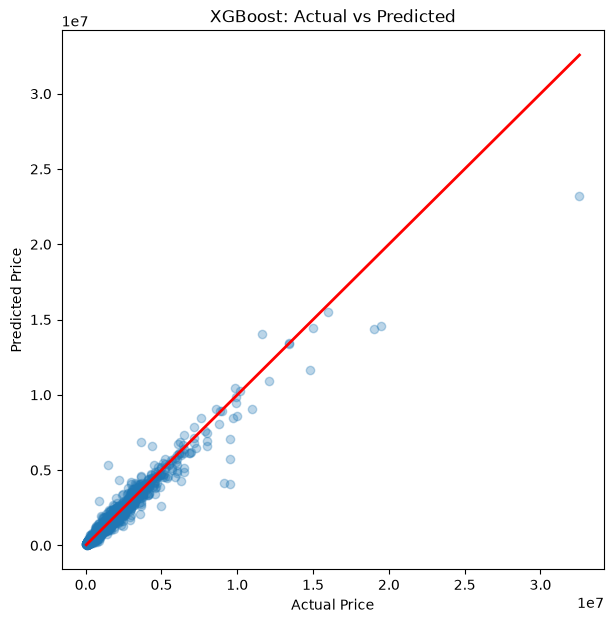

In [60]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_xgb, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost: Actual vs Predicted")

plt.show()

Insight: XGBoost produced the best predictive performance among all evaluated models. The Actual vs Predicted plot shows that most predictions lie close to the ideal diagonal line, indicating high prediction accuracy. Compared to Linear Regression and Random Forest, XGBoost significantly reduces prediction errors, especially for higher-priced vehicles. The model achieved an R² score of 0.9520, demonstrating its ability to capture complex non-linear relationships within the dataset.